In [1]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense,Conv2D,MaxPooling2D, GRU
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from google.colab import files
import io
import scipy.ndimage

In [2]:
#upload =files.upload()
#stock_data = pd.read_csv(io.BytesIO(upload['close price5.csv']))
stock_data = pd.read_csv("C:/Users/sajedeh/Downloads/DR. Amini/close price7.csv")
stock_data.head()

,Date,Iran Khodro,S*Mobarakeh Steel,S*Isf. Oil Ref.Co.,Gol-E-Gohar.,S*F. & Kh. Cement,Rouz Darou P.,Pars Switch,Iran China Clay,S*IRI Marine Co.,I. Pegah Dairy,Int. Const.,S*Sabet Khorasan,Soufian Cement,S*Saipa,S*I. N. C. Ind.
0,20251022,526,2739,4865,2031,16900,9200,4992,20450,5580,8670,536,1975,142610,484,7870
1,20251021,518,2712,4762,1972,16920,9230,4977,20500,5430,8570,534,1918,139030,484,7820
2,20251020,529,2754,4645,2010,17010,9240,4968,20440,5460,8490,520,1884,135800,494,7800
3,20251019,517,2816,4721,2042,17220,9270,4960,20480,5580,8590,510,1906,131940,499,7920
4,20251018,517,2791,4649,2014,17180,9310,4949,20410,5630,8550,521,1898,128170,485,7740


In [3]:
stock_data = stock_data.sort_values(by='Date', ascending= True)
stock_data.head()

,Date,Iran Khodro,S*Mobarakeh Steel,S*Isf. Oil Ref.Co.,Gol-E-Gohar.,S*F. & Kh. Cement,Rouz Darou P.,Pars Switch,Iran China Clay,S*IRI Marine Co.,I. Pegah Dairy,Int. Const.,S*Sabet Khorasan,Soufian Cement,S*Saipa,S*I. N. C. Ind.
1677,20181022,2685,6219,10845,8269,1592,2250,5991,11934,4995,9478,1062,3568,3454,1144,4579
1676,20181023,2587,6082,10845,7952,1530,2193,5990,11512,4859,9476,1045,3391,3454,1090,4472
1675,20181024,2526,5989,10002,7780,1460,2162,5953,11119,4641,9476,996,3224,3454,1036,4364
1674,20181027,2418,5959,9606,7791,1388,2059,5959,10869,4614,9466,969,3065,3453,1045,4286
1673,20181028,2451,5956,9467,7878,1344,2119,5948,10610,4639,9454,966,3173,3393,1080,4302


In [4]:
num_columns=stock_data.shape[1]
num_rows=stock_data.shape[0]
raw_prices = np.zeros((num_rows,num_columns-1))
for i in range(1,num_columns,1):
  for j in range(0,num_rows):
     raw_prices[j,i-1] = stock_data.iloc[j,i]

In [5]:
Relative_difference = np.zeros((num_columns-1,num_rows -1))
for i in range(num_columns-1):
  for j in range(num_rows-1):
        Relative_difference[i,j] =(raw_prices[j+1,i]- raw_prices[j,i])/raw_prices[j,i]

In [6]:
clean_RD =[]
jump_index=[]
num_jump = []
for i in range(num_columns-1):
  clean_RD.append([])
  jump_index.append([])
  k=0
  for j in range(len(Relative_difference[i])):
    if abs(Relative_difference[i][j]) >= 0.1 or abs(Relative_difference[i][j]) <= 0.00000000000000001:
      jump_index[i].append(j)
      k+= 1
      j+=1
    else:
      clean_RD[i].append(Relative_difference[i][j])
  num_jump.append(k)

In [7]:
clean_prices = []
for i in range(num_columns-1):
    clean_prices.append([])
    new_lenghth = len(Relative_difference[i])-num_jump[i]
    #print(new_lenghth)
    p = np.zeros(new_lenghth+1)
    p[0] = raw_prices[0,i]
    for l in range(1,new_lenghth+1):
        p[l] = p[l-1]*(1+clean_RD[i][l-1])
    clean_prices[i].append(p)

In [8]:
def remove_nan_element (vector):
  non_nan_indices = ~np.isnan(vector)
  vector_without_nan = vector[non_nan_indices]
  return vector_without_nan

#Separate the last_90_ for prediction
last_90_RD_clean =np.zeros((90,num_columns-1))
for i in range (num_columns-1):
  vector_without_nan=(remove_nan_element(np.array(clean_RD[i])))
  last_90_RD_clean[:,i] = vector_without_nan[-90:]


#Separate the last_90_ for Plt
last_90_prices_clean =np.zeros((90,num_columns-1))
for i in range (num_columns-1):
   vector_without_nan=(remove_nan_element(clean_prices[i][0]))
   last_90_prices_clean[:,i] = vector_without_nan[-90:]

In [9]:
#Relative_difference without the last 90 days
train_RD_clean = []
for i in range (num_columns-1):
   vector_without_nan=remove_nan_element(np.array(clean_RD[i]))
   train_RD_clean.append(vector_without_nan[:-90])

# close price without the last 90 days
train_prices_clean = []
for i in range (num_columns-1):
   vector_without_nan=remove_nan_element(clean_prices[i][0])
   train_prices_clean.append(vector_without_nan[:-90])

In [10]:
def split_to_squenses(data,step,future):
   X, Y = [], []
   for i in range(len(data)-step-future):
     d=i+step
     X.append(data[i:d])
     Y.append(data[d:(d+future)])
   return np.array(X), np.array(Y)

In [11]:
from random import choices
def bootstraping(xtrain, nboot):
  indexes = []
  length = xtrain.shape[0]
  indices = list(range(1, length))
  for i in range(nboot):
    boot = choices(indices, k = length)
    indexes.append(boot)
  return indexes

In [12]:
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Reshape

def create_CNN_model(x_train,y_train):
  
        model = Sequential([
        # --- Block 1 ---
        Conv1D(8, kernel_size=5, activation='relu', padding='same',
               input_shape=(x_train.shape[1], x_train.shape[2])),
        #BatchNormalization(),
        Reshape((x_train.shape[1],8,1)),
        # --- Block 2 ---
        Conv2D(4, kernel_size= (3,8), activation='relu', padding='valid'),
        #Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        #BatchNormalization(),
        #Dropout(0.1),

        # --- Bottleneck ---
        #GlobalMaxPooling1D(),
        MaxPooling2D(pool_size = 3, padding='same'),
        Flatten(), 
        Dropout(0.1),
        # --- Dense Layers ---
        #Dense(64, activation='relu'),
        Dense(90)
        ])

        model.compile(
          optimizer=Adam(learning_rate=5e-4),
          loss='huber',
          metrics=['mse']
        )

        return model

In [14]:
# We create indices for 35 scenarios and then you choose 5, 10, 15, 20, 25 , 30 and 35 scenarios from that.
#for i,share in enumerate(train_RD_clean):
#  x_train,y_train = split_to_squenses(share,900,90)
#  df_index = pd.DataFrame(bootstraping(x_train,35))
#  filepath = f'E:/desktop/javadi-soleimani/15 assets/indexes_35/inds {i}.xlsx'
#  df_index.to_excel(filepath, index=False)

In [15]:
# Download once and use it for everyone.
#!zip -r /content/all_results_gru.zip /content
#from google.colab import files
#files.download("/content/all_results_cnn.zip")

In [13]:
inds = []
for sh in range(num_columns-1):
  #upload =files.upload()
  #inds.append(pd.read_excel(io.BytesIO(upload[f'inds {sh}.xlsx'])))
    inds.append(pd.read_excel(f'C:/Users/sajedeh/Downloads/DR. Amini/indexes_35/indexes_35/inds {sh}.xlsx'))

In [15]:
nboot = 15 # number of Scenarios

In [19]:
prediction_y_not_boot2 = []
prediction_y_boot2 = []
num_assets = 15
for index in range(num_assets):
  prediction_y_not_boot2.append([np.array(pd.read_excel(f'C:/Users/sajedeh/Downloads/DR. Amini/predictions_cnn/predictions/Prediction_not_boot2 {index+1}.xlsx')).reshape((90,))])
  prediction_y_boot2.append([])
  for b in range(nboot):
    prediction_y_boot2[index].append([np.array(pd.read_excel(f'C:/Users/sajedeh/Downloads/DR. Amini/predictions_cnn/predictions/Prediction2 {index+1}{b+1}.xlsx')).reshape((90,))])

In [20]:
#import warnings
#history_boot2 = []
#prediction_y_not_boot2 = []
#history_not_boot2 = []
#prediction_y_boot2 = []
#model2 = []
#modelb2 = []
#cntr1 = 0
#for index,share in enumerate(train_RD_clean):
#  cntr2 = 0
#  print("property",cntr1+1)
#  x_train,y_train = split_to_squenses(share,900,90)
#  x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
#  length = len(train_RD_clean[cntr1])
#  x_test = train_RD_clean[cntr1][(length - 900):length]
#  x_test = np.reshape(x_test, (1, len(x_test), 1))
#  model2.append(create_CNN_model(x_train,y_train))
#  warnings.filterwarnings("ignore")
#  fited = model2[cntr1].fit(x_train, y_train, epochs=100, batch_size=100, shuffle=False,verbose=0)
#  history_not_boot2.append(fited)
#  warnings.filterwarnings("ignore")
#  yy = model2[cntr1].predict(x_test)
#  yy_array = np.array(yy)
#  df_PNB = pd.DataFrame(yy_array)
#  filepath = f'E:/desktop/javadi-soleimani/15 assets/predictions/Prediction_not_boot2 {index+1}.xlsx'
#  df_PNB.to_excel(filepath, index=False)
#  prediction_y_not_boot2.append(yy)
#  modelb2.append([])
#  history_boot2.append([])
#  prediction_y_boot2.append([])
#  for b in range(nboot):
#    print("bootstrap",cntr2+1)
#    indx = np.asarray(inds[cntr1])[b,:]
#    x_boot = x_train[indx,:]
#    y_boot = y_train[indx,:]
#    modelb2[cntr1].append(create_CNN_model(x_boot,y_boot))
#    warnings.filterwarnings("ignore")
#    fited = modelb2[cntr1][cntr2].fit(x_boot, y_boot, epochs=100, batch_size=100, shuffle=False,verbose=0)
#    history_boot2[cntr1].append(fited)
#    warnings.filterwarnings("ignore")
#    yy = modelb2[cntr1][cntr2].predict(x_test)
#    yy_array = np.array(yy)
#    df_PB = pd.DataFrame(yy_array)
#    filepath = f'E:/desktop/javadi-soleimani/15 assets/predictions/Prediction2 {index+1}{b+1}.xlsx'
#    df_PB.to_excel(filepath, index=False)
#    prediction_y_boot2[cntr1].append(yy)
#    cntr2 = cntr2 + 1
#  cntr1 = cntr1 + 1

In [21]:
num_assets = 15
for i in range(num_assets):
   print('mse for without bootstrap asset',i, '=')
   print(sum((prediction_y_not_boot2[i][0] - last_90_RD_clean[:,i])**2))
   print('mae for without bootstrap asset',i, '=')
   print(sum(abs(prediction_y_not_boot2[i][0] - last_90_RD_clean[:,i])))

mse for without bootstrap asset 0 =
0.0485216702771267
mae for without bootstrap asset 0 =
1.8605843471163916
mse for without bootstrap asset 1 =
0.060162332304199
mae for without bootstrap asset 1 =
1.8259513224626804
mse for without bootstrap asset 2 =
0.048578712448211506
mae for without bootstrap asset 2 =
1.7221603343916285
mse for without bootstrap asset 3 =
0.03436821139336262
mae for without bootstrap asset 3 =
1.431218438229878
mse for without bootstrap asset 4 =
0.051298512148735015
mae for without bootstrap asset 4 =
1.787366542113803
mse for without bootstrap asset 5 =
0.0167228816074872
mae for without bootstrap asset 5 =
0.8905084578135094
mse for without bootstrap asset 6 =
0.01346918572702697
mae for without bootstrap asset 6 =
0.7895353517864809
mse for without bootstrap asset 7 =
0.03309793896331336
mae for without bootstrap asset 7 =
1.2515194758640151
mse for without bootstrap asset 8 =
0.05479529749036887
mae for without bootstrap asset 8 =
1.9062138820749812
mse f

In [22]:
num_assets = 15
Mse =[]
Mae =[]
for i in range (num_assets):
  Mse.append([])
  Mae.append([])
  for j in range(nboot):
     Mse[i].append(sum(prediction_y_boot2[i][j][0] - last_90_RD_clean[:,i])**2)
     Mae[i].append(sum(abs(prediction_y_boot2[i][j][0] - last_90_RD_clean[:,i])))

In [23]:
for i in range (num_assets):
   Mean_Mse= np.mean(Mse[i])
   STD_Mse = np.std(Mse[i])
   print(Mean_Mse, STD_Mse)

0.025570980252315585 0.027536201040805137
0.26527282456719387 0.0987262005171575
0.011201450857123476 0.008870660278929294
0.005516480491804093 0.00679297890872115
0.18568806183028602 0.0688936577779675
0.008887962162795601 0.01207558149110177
0.033546524212960914 0.030778632764907488
0.29231037109182123 0.05577641152747258
0.6733090557449851 0.20476888548993138
0.011194304502136971 0.009105296828925887
0.15431500952359006 0.10260993648472243
0.02876380944209381 0.032849070343832915
0.011447822738869184 0.010634875025294435
0.013917999623724357 0.01371364979583668
0.05183096789831562 0.027365089071504783


In [24]:
for i in range (num_assets):
   Mean_Mae= np.mean(Mae[i])
   STD_Mae = np.std(Mae[i])
   print(Mean_Mae, STD_Mae)

2.0052089555308164 0.07919217065467204
1.9537917178824311 0.09466409077328679
1.9498029035874669 0.08781898697141026
1.508839402858586 0.07897380360035673
1.798499378113659 0.07209927994991523
1.156641170455236 0.0863897489068383
1.0536672594953533 0.09896508894954685
1.4905884262312328 0.11440875900822904
1.8958881907813363 0.10038592294720491
1.3760678578992516 0.1297486325172071
1.8007978127187634 0.12951330773035422
1.6581849991329924 0.13104339407906174
1.791205495811157 0.06356938051251113
1.9120594453048205 0.0753677727761387
1.7332402740530297 0.08329347603432599


In [25]:
num_assets = 15
price_prediction_not_boot2 = []
#for i in range(num_columns-1):
for i in range(num_assets):
    p = np.zeros(90)
    p[0] = train_prices_clean[i][len(Relative_difference[1])-num_jump[i]-90]
    for k in range(1,90):
        p[k] = p[k-1]*(1+prediction_y_not_boot2[i][0][k-1])
    price_prediction_not_boot2.append(p)

In [26]:
price_prediction2 = []
#for i in range(num_columns-1):
for i in range(num_assets):
    p = np.zeros((nboot,90))
    for j in range(nboot):
        p[j,0] = train_prices_clean[i][len(Relative_difference[1])-num_jump[i]-90]
        for k in range(1,90):
            p[j,k] = p[j,k-1]*(1+prediction_y_boot2[i][j][0][k-1])
    price_prediction2.append(p)

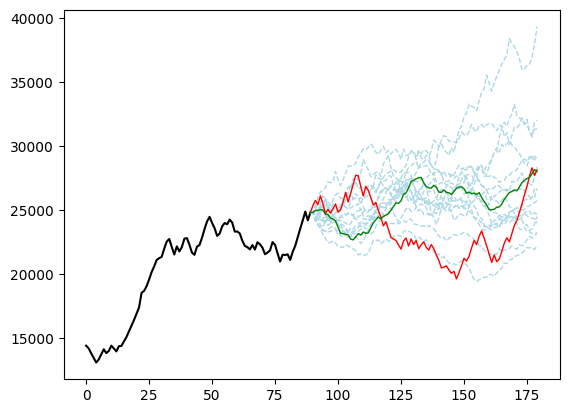

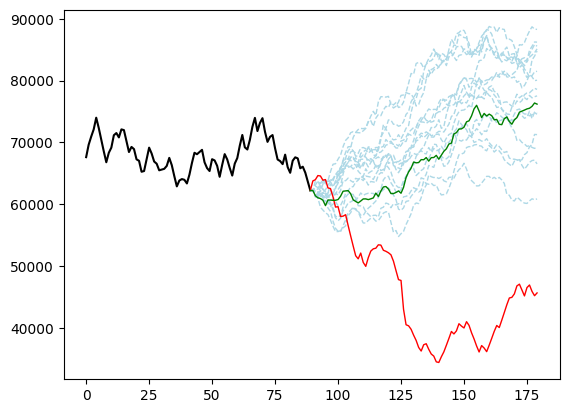

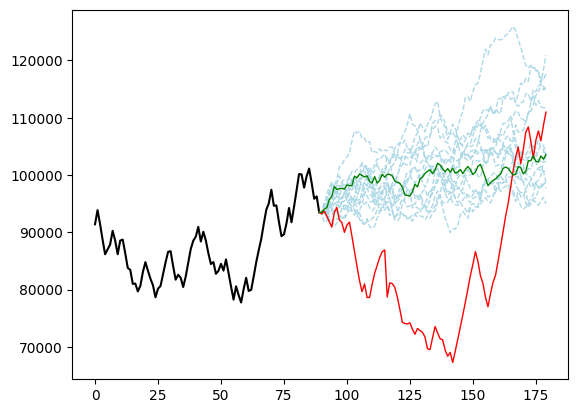

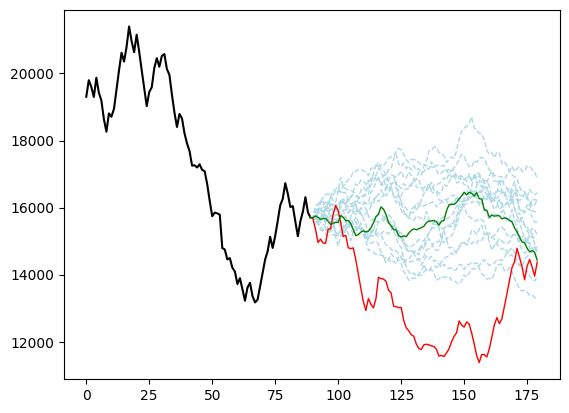

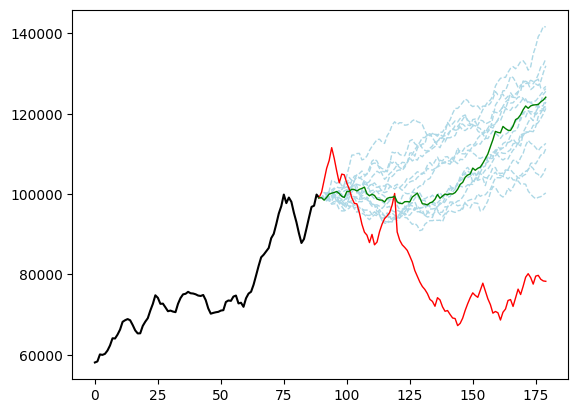

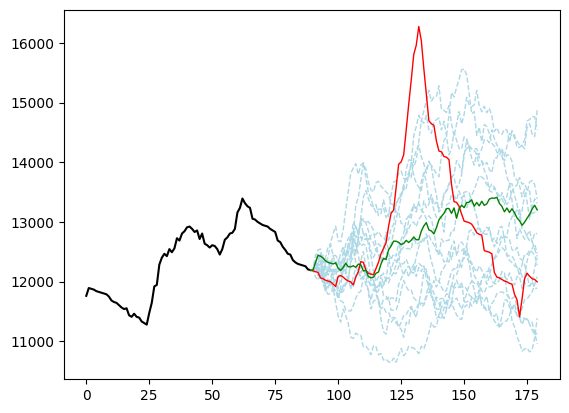

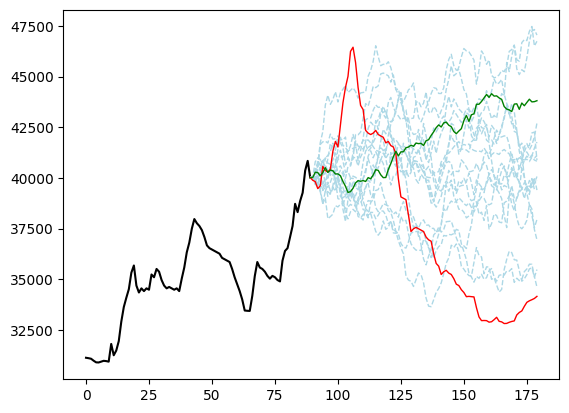

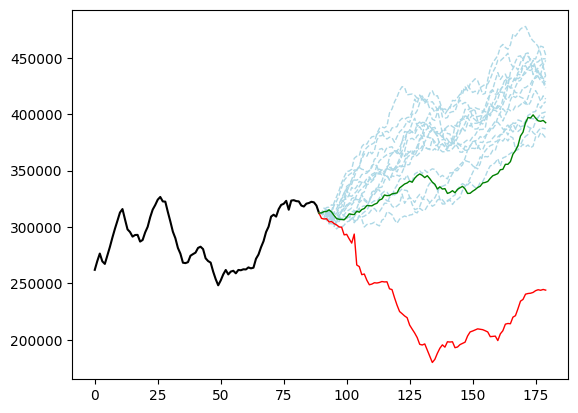

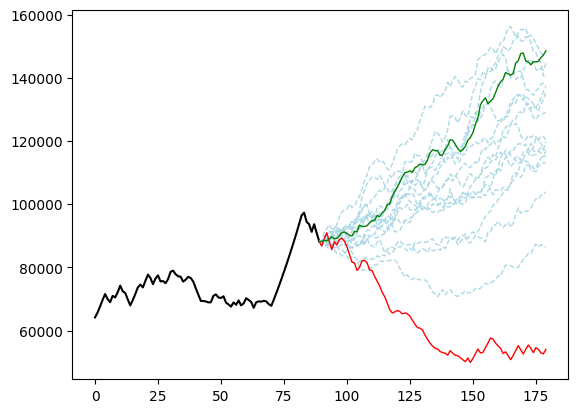

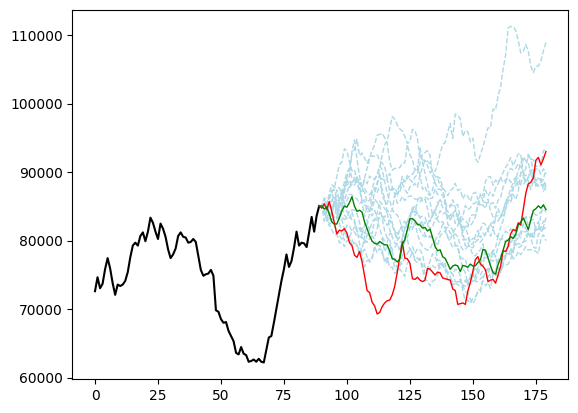

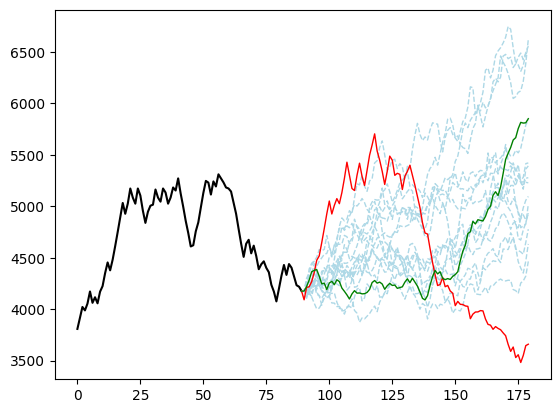

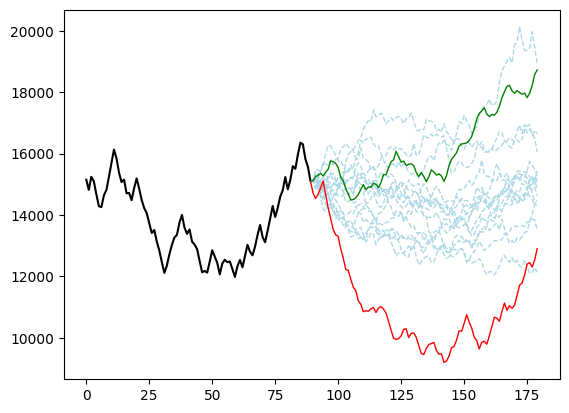

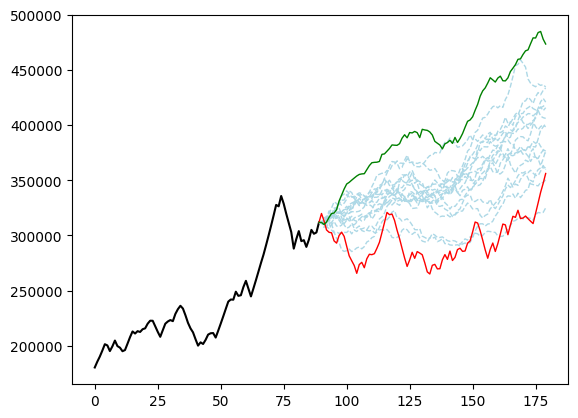

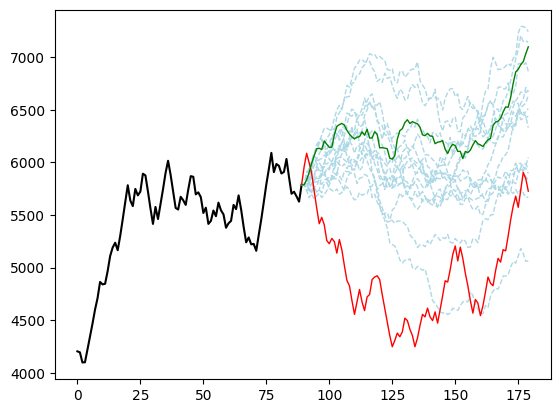

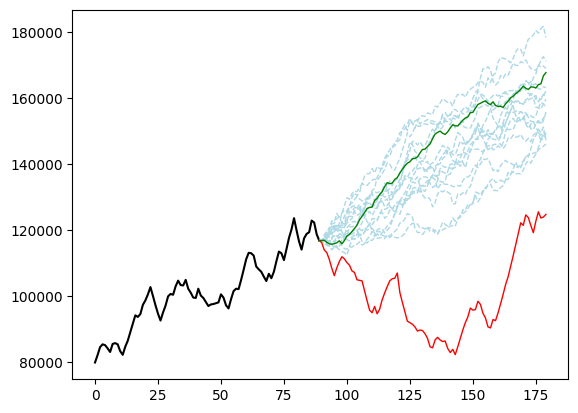

In [29]:
numboot = 15 # Do it separately for 5, 10, 15, 20, 25 , 30 and 35.
#for i in range(num_columns-1):
for i in range(num_assets):
  end = len(train_prices_clean[i])
  beg = end - 90
  time = range(len(train_prices_clean[i][beg:end]))
  plt.plot(time,train_prices_clean[i][beg:end],color="black")
  tim = range(len(train_prices_clean[i][beg:end])-1,len(train_prices_clean[i][beg:end])+90)
  for j in range(0,numboot):
    a = np.hstack([train_prices_clean[i][end-1],price_prediction2[i][j][:]])
    plt.plot(tim, a, color = 'lightblue', linestyle='dashed', linewidth=1)
  b = np.hstack([train_prices_clean[i][end-1],last_90_prices_clean[:,i]])
  plt.plot(tim,b,color = "red", linewidth=1)
  c = np.hstack([train_prices_clean[i][end-1],price_prediction_not_boot2[i][:]])
  plt.plot(tim,c,color = "green", linewidth=1)
  #plt.savefig(f'E:/desktop/javadi-soleimani/15 assets/figures_CNN/stock_c_{i+1}_{numboot}.jpg')
  plt.show()
  #files.download(f'stock_g {i+1}_{numboot}.jpg')

In [28]:
def calculate_mean_cov(y_pred, nboot):
  mean = np.zeros((nboot, num_assets))
  std = np.zeros((nboot,num_assets))
  for i in range(num_assets):
    for j in range(nboot):
      mean[j,i] = np.mean(y_pred[i][j])
      std [j,i] = np.std(y_pred[i][j])
  Covariance_Matrix = np.zeros((nboot,num_assets,num_assets))
  for j in range(nboot):
    Cov_between = np.array([y_pred[i][j] for i in range(num_assets)])
    CC= Cov_between.reshape(Cov_between.shape[0], Cov_between.shape[2])
    Covariance_Matrix[j,:,:] = np.cov(CC)
  return mean, std, Covariance_Matrix

nboot = 35
m2_30, s2_30, c2_30 = calculate_mean_cov(prediction_y_boot2,nboot)


In [33]:
import numpy as np
from scipy.optimize import minimize , Bounds
from cvxopt import matrix, solvers
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
#from google.colab import files
import os
import io
import xlrd

In [35]:
Mean30 = m2_30
covariance30 = []
for i in range(nboot):
  covariance30.append(c2_30[i,:,:])

In [37]:
MEAN30 = []
for i in range (nboot):
    Mean_row30 =np.zeros((1,num_assets))
    Mean_row30[0,:] = Mean30[i,:]
    MEAN30.append(Mean_row30)

In [38]:
import random

In [39]:
#Senario_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
Optimal_value30 =[]
Optimal_solution30 =[]
for i in range(nboot):
  sigma = covariance30[i]
  Q = matrix(sigma, tc='d')
  P = matrix(-MEAN30[i], tc='d').T
  G = matrix(-np.eye(num_assets), tc='d')
  h = matrix(np.zeros(num_assets), tc='d')
  A = matrix(np.ones(num_assets), tc='d').T
  b = matrix(1.0)
  Optimal_value_Lambda = []
  Optimal_solution_Lambda = []
  for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]: 
      sol = solvers.qp(2*Lambda*Q,(1-Lambda)*P,G,h,A,b)
      Optimal_value_Lambda.append(sol['primal objective'])
      Optimal_solution_Lambda.append(sol['x'])
  Optimal_solution30.append(Optimal_solution_Lambda)
  Optimal_value30.append(Optimal_value_Lambda)
solvers.options.update(old_settings)

In [40]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for j in range(nboot):
   print("Bootstrap sample",j+1)
   for i in range(9):
    print("lambda =", Lambda_list[i])
    print(Optimal_solution30[j][i][:])

Bootstrap sample 1
lambda = 0.1
[ 1.55e-07]
[ 3.93e-07]
[ 3.26e-07]
[ 2.95e-07]
[ 3.47e-07]
[ 1.99e-07]
[ 2.37e-07]
[ 1.92e-07]
[ 1.00e+00]
[ 3.12e-07]
[ 5.31e-07]
[ 1.96e-07]
[ 2.62e-07]
[ 2.10e-07]
[ 5.48e-07]

lambda = 0.2
[ 1.98e-07]
[ 4.50e-07]
[ 3.82e-07]
[ 3.49e-07]
[ 4.05e-07]
[ 2.45e-07]
[ 2.88e-07]
[ 1.88e-07]
[ 1.00e+00]
[ 3.69e-07]
[ 5.81e-07]
[ 2.44e-07]
[ 3.16e-07]
[ 2.60e-07]
[ 5.66e-07]

lambda = 0.3
[ 2.47e-07]
[ 5.06e-07]
[ 4.40e-07]
[ 4.08e-07]
[ 4.65e-07]
[ 2.96e-07]
[ 3.45e-07]
[ 1.81e-07]
[ 1.00e+00]
[ 4.29e-07]
[ 6.25e-07]
[ 2.99e-07]
[ 3.74e-07]
[ 3.16e-07]
[ 5.70e-07]

lambda = 0.4
[ 2.97e-07]
[ 5.51e-07]
[ 4.91e-07]
[ 4.61e-07]
[ 5.19e-07]
[ 3.46e-07]
[ 3.99e-07]
[ 1.73e-07]
[ 1.00e+00]
[ 4.84e-07]
[ 6.52e-07]
[ 3.54e-07]
[ 4.29e-07]
[ 3.72e-07]
[ 5.49e-07]

lambda = 0.5
[ 3.32e-07]
[ 5.53e-07]
[ 5.06e-07]
[ 4.83e-07]
[ 5.38e-07]
[ 3.73e-07]
[ 4.29e-07]
[ 1.58e-07]
[ 1.00e+00]
[ 5.09e-07]
[ 6.27e-07]
[ 3.89e-07]
[ 4.57e-07]
[ 4.07e-07]
[ 4.65e-07]

lambda = 0.

In [41]:
OPT_X =[]
for l in range(nboot):
  OX =np.zeros((num_assets,num_assets))
  for n in range(9):
    for k in range(num_assets):
      OX[k,n]=Optimal_solution30[l][n][k]
  OPT_X.append(OX)

In [42]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(nboot):
  print("Bootstrap sample",i+1)
  sigma = covariance30[i]
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    a = np.dot(OPT_X[i][:,k].T, sigma @ OPT_X[i][:,k])
    print(a)

Bootstrap sample 1
Lambda = 0.1
0.0001798803314532484
Lambda = 0.2
0.00017988010148472543
Lambda = 0.3
0.0001798798621317429
Lambda = 0.4
0.0001798796521134081
Lambda = 0.5
0.00017987959545123235
Lambda = 0.6
0.0001798801120515471
Lambda = 0.7
0.00017988057203863978
Lambda = 0.8
0.00016168383890161157
Lambda = 0.9
7.522997383071139e-05
Bootstrap sample 2
Lambda = 0.1
5.255505146937189e-05
Lambda = 0.2
5.255465359720576e-05
Lambda = 0.3
5.255347350975733e-05
Lambda = 0.4
5.2548945327175384e-05
Lambda = 0.5
5.2515828607978016e-05
Lambda = 0.6
5.254445891046258e-05
Lambda = 0.7
4.9300968685109914e-05
Lambda = 0.8
4.4157037956966804e-05
Lambda = 0.9
3.244280501381686e-05
Bootstrap sample 3
Lambda = 0.1
0.00022553993663827762
Lambda = 0.2
0.00022553951074982828
Lambda = 0.3
0.00022553896074396933
Lambda = 0.4
0.0002255386645807608
Lambda = 0.5
0.00022553906788420905
Lambda = 0.6
0.00022553623794089797
Lambda = 0.7
0.00019166661276856533
Lambda = 0.8
0.00012847034449990055
Lambda = 0.9
6.583

In [43]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for m in range(nboot):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    u = np.dot(MEAN30[m], OPT_X[m][:,k])
    print(u)

Bootstrap sample 1
Lambda = 0.1
[0.00504259]
Lambda = 0.2
[0.00504259]
Lambda = 0.3
[0.00504258]
Lambda = 0.4
[0.00504258]
Lambda = 0.5
[0.00504258]
Lambda = 0.6
[0.00504258]
Lambda = 0.7
[0.00504259]
Lambda = 0.8
[0.0049731]
Lambda = 0.9
[0.00446271]
Bootstrap sample 2
Lambda = 0.1
[0.00344158]
Lambda = 0.2
[0.00344158]
Lambda = 0.3
[0.00344157]
Lambda = 0.4
[0.00344156]
Lambda = 0.5
[0.00344149]
Lambda = 0.6
[0.00344156]
Lambda = 0.7
[0.00343462]
Lambda = 0.8
[0.00341935]
Lambda = 0.9
[0.00333555]
Bootstrap sample 3
Lambda = 0.1
[0.00517014]
Lambda = 0.2
[0.00517014]
Lambda = 0.3
[0.00517013]
Lambda = 0.4
[0.00517013]
Lambda = 0.5
[0.00517013]
Lambda = 0.6
[0.00517013]
Lambda = 0.7
[0.00509707]
Lambda = 0.8
[0.00491079]
Lambda = 0.9
[0.00454648]
Bootstrap sample 4
Lambda = 0.1
[0.00573495]
Lambda = 0.2
[0.00573495]
Lambda = 0.3
[0.00573495]
Lambda = 0.4
[0.00573495]
Lambda = 0.5
[0.00573495]
Lambda = 0.6
[0.00573495]
Lambda = 0.7
[0.00573495]
Lambda = 0.8
[0.00573496]
Lambda = 0.9
[0

In [44]:
for m in range(nboot):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    print(Optimal_value30[m][k])

Bootstrap sample 1
Lambda = 0.1
-0.004520342112752131
Lambda = 0.2
-0.003998093040920611
Lambda = 0.3
-0.003475844430659912
Lambda = 0.4
-0.002953596580906932
Lambda = 0.5
-0.00243135001756202
Lambda = 0.6
-0.001909105744739812
Lambda = 0.7
-0.0013868620792052931
Lambda = 0.8
-0.0008652738321506994
Lambda = 0.9
-0.0003785642705394198
Bootstrap sample 2
Lambda = 0.1
-0.003092164971296561
Lambda = 0.2
-0.0027427502992885527
Lambda = 0.3
-0.0023933355499103346
Lambda = 0.4
-0.0020439180624360004
Lambda = 0.5
-0.0016944893018020779
Lambda = 0.6
-0.0013450990497700546
Lambda = 0.7
-0.0009958767740242025
Lambda = 0.8
-0.0006485453599368545
Lambda = 0.9
-0.0003043569536440991
Bootstrap sample 3
Lambda = 0.1
-0.004630571727336091
Lambda = 0.2
-0.004091000576467449
Lambda = 0.3
-0.003551429354944207
Lambda = 0.4
-0.003011860396624904
Lambda = 0.5
-0.0024722947002786388
Lambda = 0.6
-0.0019327289198556438
Lambda = 0.7
-0.0013949533467891633
Lambda = 0.8
-0.000879382428666888
Lambda = 0.9
-0.0003

In [45]:
def objective_function_5(X0,Lambda,index_Lambda, nb):
    p_2 = 1/nb
    X = np.zeros((1,num_assets))
    for j in range(num_assets):
      X[0,j]=X0[j]
    total_sum = 0
    for i in range(nb):
        sigma = covariance30[i]
        mean_matrix = MEAN30[i]
        V_s = Optimal_value30[i][index_Lambda]
        term1 = np.dot(X, sigma @ X.T)
        term2 = np.dot(mean_matrix, X.T)
        term3 = V_s
        total_sum += p_2*(Lambda*term1 -(1-Lambda)*term2 - term3)**2

    return total_sum

In [47]:
from scipy.optimize import LinearConstraint
linear_constraint = LinearConstraint([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]], [1], [1])
#linear_constraint = LinearConstraint([[1,1,1,1,1,1,1,1,1,1,1,1]], [1], [1])

In [48]:
#Problem_5
nboot = 15
X_0 = [1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15]
#X_0 = [1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12]

# constarnt = {'type':'eq', 'fun': constraint_1}
Optimal_solution15_5=[]
Optimal_value15_5=[]
for i in range(9):
   random.seed(13600613)
   opt_solution = minimize(objective_function_5,X_0,args=(Lambda_list[i], i, nboot),bounds=Bounds(0,np.inf),constraints=[linear_constraint] , method='trust-constr')
   Optimal_solution15_5.append(opt_solution.x)
   Optimal_value15_5.append(opt_solution.fun)

print("Optimal solution for nboot=15:", Optimal_solution15_5)
print("Optimal value for nboot=15:", Optimal_value15_5)


Optimal solution for nboot=15: [array([0.066666  , 0.06666762, 0.06666635, 0.06666439, 0.06666749,
       0.06666522, 0.06666494, 0.06666866, 0.06666911, 0.06666516,
       0.06666807, 0.06666479, 0.06666765, 0.06666593, 0.06666863]), array([0.06666614, 0.06666742, 0.06666642, 0.06666487, 0.06666732,
       0.06666553, 0.06666531, 0.06666823, 0.0666686 , 0.06666548,
       0.06666777, 0.06666518, 0.06666744, 0.06666609, 0.06666822]), array([0.06666626, 0.06666724, 0.06666648, 0.0666653 , 0.06666716,
       0.0666658 , 0.06666563, 0.06666786, 0.06666814, 0.06666576,
       0.06666751, 0.06666554, 0.06666726, 0.06666622, 0.06666785]), array([0.06666637, 0.06666709, 0.06666653, 0.06666567, 0.06666703,
       0.06666603, 0.06666591, 0.06666754, 0.06666774, 0.066666  ,
       0.06666728, 0.06666584, 0.0666671 , 0.06666634, 0.06666753]), array([0.06666646, 0.06666696, 0.06666657, 0.06666598, 0.06666692,
       0.06666623, 0.06666614, 0.06666727, 0.06666741, 0.06666621,
       0.06666709, 0.0

In [49]:
#Risk of Problem_5

nboot = 15
Risk15_5 =[]
p_2 = 1/nboot
for k in range(9):
  print("Lambda =", Lambda_list[k])
  total_sum = 0
  for i in range(nboot):
    sigma = covariance30[i]
    total_sum = total_sum + p_2 * np.dot(Optimal_solution15_5[k].T, sigma @ Optimal_solution15_5[k])
  print("risk for nboot=15 is ",total_sum)
  Risk15_5.append(total_sum)

Lambda = 0.1
risk for nboot=15 is  8.152838433238242e-06
Lambda = 0.2
risk for nboot=15 is  8.152837804408537e-06
Lambda = 0.3
risk for nboot=15 is  8.152837260102692e-06
Lambda = 0.4
risk for nboot=15 is  8.152836755867997e-06
Lambda = 0.5
risk for nboot=15 is  8.152836351462751e-06
Lambda = 0.6
risk for nboot=15 is  8.152835997991456e-06
Lambda = 0.7
risk for nboot=15 is  8.152835750977963e-06
Lambda = 0.8
risk for nboot=15 is  8.152835566209894e-06
Lambda = 0.9
risk for nboot=15 is  8.152835457915485e-06


In [50]:
#Retern of Problem_5
nboot = 15
p_2 = 1/nboot
Retern15_5 =[]
for k in range(9):
  print("Lambda =", Lambda_list[k])
  total_sum = 0
  for i in range(nboot):
    total_sum = total_sum+ p_2 *np.dot(MEAN30[i], Optimal_solution15_5[k])
  print("return for nboot=15 is ", total_sum)
  Retern15_5.append(total_sum)

Lambda = 0.1
return for nboot=15 is  [0.00162953]
Lambda = 0.2
return for nboot=15 is  [0.00162952]
Lambda = 0.3
return for nboot=15 is  [0.00162952]
Lambda = 0.4
return for nboot=15 is  [0.00162951]
Lambda = 0.5
return for nboot=15 is  [0.00162951]
Lambda = 0.6
return for nboot=15 is  [0.0016295]
Lambda = 0.7
return for nboot=15 is  [0.0016295]
Lambda = 0.8
return for nboot=15 is  [0.0016295]
Lambda = 0.9
return for nboot=15 is  [0.0016295]


In [51]:
#import matplotlib.pyplot as plt

#SRisk15_5 = [x for x,_ in sorted(zip(Risk15_5,Retern15_5))]
#SRetern15_5 = [x for _,x in sorted(zip(Risk15_5,Retern15_5))]

#plt.figure(figsize=(8,6))
#plt.plot(SRisk15_5, SRetern15_5, color='blue', marker='o', linestyle='-')
#plt.xlabel('Risk', fontsize=14)
#plt.ylabel('Return', fontsize=14)
#plt.title('Pareto frontier for 15 bootstraps SO solution', fontsize=16)
#plt.legend()
#plt.grid(True)
#plt.savefig(f'E:/desktop/javadi-soleimani/15 assets/figures_CNN3/PF_nboot15_SO.jpg')
#plt.show()
#files.download(f'PF_nboot15_SO.jpg')


In [52]:
pred_nb = np.array(prediction_y_not_boot2).reshape((num_assets,90))
mean =np.mean(pred_nb, axis=1)
mean.shape

(15,)

In [53]:
covariance_Matrix =np.cov(pred_nb, rowvar=True)
covariance_Matrix.shape

(15, 15)

In [54]:
#Mean_Variance_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
sigma = covariance_Matrix
P = matrix(sigma, tc='d')
q = - matrix(mean.astype(np.double), tc='d')
G = matrix(-np.eye(num_assets), tc='d')
h = matrix(np.zeros(num_assets), tc='d')
A = matrix(np.ones(num_assets), tc='d').T
b = matrix(1.0)
Optimal_value_Lambda =[]
Optimal_solution_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(2*Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_value_Lambda.append(sol['primal objective'])
  Optimal_solution_Lambda.append(sol['x'])
solvers.options.update(old_settings)

In [55]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(Optimal_value_Lambda[i])

lambda = 0.1
-0.005269917665062296
lambda = 0.2
-0.004674872612467106
lambda = 0.3
-0.004079827817829902
lambda = 0.4
-0.0034847834096034956
lambda = 0.5
-0.0028897395836962655
lambda = 0.6
-0.0022946967382181526
lambda = 0.7
-0.0016996553404338651
lambda = 0.8
-0.0011046113752565844
lambda = 0.9
-0.0005095083534215188


In [56]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_No =[]
for i in range(9):
  #print("lambda =", Lambda_list[i])
  X = np.zeros(num_assets)
  for j in range(num_assets):
    X[j] = Optimal_solution_Lambda[i][j]
  #print(X)
  X_OPT_No.append(X)

In [57]:
#Risk
Risk_No =[]
sigma = covariance_Matrix
for i in range(9):
   print("lambda =", Lambda_list[i])
   print(np.dot(X_OPT_No[i].T, sigma @ X_OPT_No[i]))
   Risk_No.append(np.dot(X_OPT_No[i].T, sigma @ X_OPT_No[i]))

#print(Risk_No)

lambda = 0.1
8.54780243071273e-05
lambda = 0.2
8.547796972391272e-05
lambda = 0.3
8.547791574397461e-05
lambda = 0.4
8.547787171458698e-05
lambda = 0.5
8.547786068158532e-05
lambda = 0.6
8.547795367752457e-05
lambda = 0.7
8.547832409164322e-05
lambda = 0.8
8.547804212414756e-05
lambda = 0.9
8.484767990820075e-05


In [58]:
#Retern
Retern_No =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(np.dot(mean, X_OPT_No[i]))
  Retern_No.append(np.dot(mean, X_OPT_No[i]))

#print(Retern_No)

lambda = 0.1
0.005864961630547787
lambda = 0.2
0.005864960258014859
lambda = 0.3
0.005864958846504422
lambda = 0.4
0.005864957597148884
lambda = 0.5
0.005864957028074116
lambda = 0.6
0.005864958776061665
lambda = 0.7
0.0058649672243267165
lambda = 0.8
0.0058649690447795146
lambda = 0.9
0.005858712653388998


In [59]:
#SRisk_No = [x for x,_ in sorted(zip(Risk_No,Retern_No))]
#SRetern_No = [x for _,x in sorted(zip(Risk_No,Retern_No))]
#
#plt.figure(figsize=(8,6))
#plt.plot(SRisk_No, SRetern_No, color='red', marker='o', linestyle='-')
#plt.xlabel('Risk', fontsize=14)
#plt.ylabel('Return', fontsize=14)
#plt.title('Pareto frontier for without bootstrap solution', fontsize=16)
#plt.legend()
#plt.grid(True)
#plt.savefig(f'E:/desktop/javadi-soleimani/15 assets/figures_CNN3/PF_No.jpg')
#plt.show()
#files.download(f'PF_No.jpg')

In [60]:
meanr =np.mean(last_90_RD_clean, axis=0)[0:num_assets]
meanr.shape

(15,)

In [61]:
covariance_Matrixr =np.cov(last_90_RD_clean, rowvar=False)[0:num_assets,0:num_assets]
covariance_Matrixr.shape

(15, 15)

In [62]:
#Mean_Variance_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
sigmar = covariance_Matrixr
P = matrix(sigmar, tc='d')
q = -matrix(meanr.astype(np.double), tc='d')
G = matrix(-np.eye(num_assets), tc='d')
h = matrix(np.zeros(num_assets), tc='d')
A = matrix(np.ones(num_assets), tc='d').T
b = matrix(1.0)
Optimal_valuer_Lambda =[]
Optimal_solutionr_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(2*Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_valuer_Lambda.append(sol['primal objective'])
  Optimal_solutionr_Lambda.append(sol['x'])
solvers.options.update(old_settings)

In [63]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_r =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  X = np.zeros(num_assets)
  for j in range(num_assets):
    X[j] = Optimal_solutionr_Lambda[i][j]
  print(X)
  X_OPT_r.append(X)

lambda = 0.1
[6.04497373e-07 8.71317800e-08 9.99995854e-01 2.41527739e-07
 1.16979026e-07 3.85841364e-07 1.59112354e-07 1.09376409e-07
 5.64368886e-08 7.14158063e-07 1.94509233e-07 1.60293046e-07
 2.43568793e-07 4.28104721e-07 6.44880577e-07]
lambda = 0.2
[1.61943849e-06 1.58197653e-07 9.99994465e-01 3.23161319e-07
 1.98212248e-07 4.62661619e-07 2.52373380e-07 1.90086246e-07
 1.14754742e-07 5.28987795e-07 2.88254596e-07 2.41235893e-07
 2.10566910e-07 4.75099666e-07 4.72028262e-07]
lambda = 0.3
[2.68690052e-04 2.15737007e-07 9.99721659e-01 4.12755752e-07
 2.77038597e-07 5.90715578e-07 3.65665018e-07 2.69992119e-07
 1.63307462e-07 2.42329298e-07 4.02604905e-07 3.14519987e-07
 5.76220860e-06 5.47792853e-07 8.64113660e-08]
lambda = 0.4
[1.66708281e-01 3.84137615e-08 8.33247939e-01 7.58021025e-08
 4.62656053e-08 1.22930687e-07 5.79842491e-08 4.44189952e-08
 2.77275571e-08 3.87047682e-07 6.71919669e-08 5.67832055e-08
 4.24992437e-05 1.24330268e-07 2.32316265e-07]
lambda = 0.5
[2.66415383e-01

In [64]:
#Risk
Risk_r =[]
sigmar = covariance_Matrixr
for i in range(9):
   print("lambda =", Lambda_list[i])
   print(np.dot(X_OPT_r[i].T, sigmar @ X_OPT_r[i]))
   Risk_r.append(np.dot(X_OPT_r[i].T, sigmar @ X_OPT_r[i]))

#print(Risk_r)

lambda = 0.1
0.0005746269325937665
lambda = 0.2
0.0005746253075063574
lambda = 0.3
0.0005742995965230032
lambda = 0.4
0.00040511148232684843
lambda = 0.5
0.00030031318585709943
lambda = 0.6
0.00024361749634272187
lambda = 0.7
0.00021287975575865682
lambda = 0.8
0.00015589096064278846
lambda = 0.9
7.653479483629225e-05


In [65]:
#Retern
Retern_r =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(np.dot(meanr, X_OPT_r[i]))
  Retern_r.append(np.dot(meanr, X_OPT_r[i]))

#print(Retern_r)

lambda = 0.1
0.0021952387789821513
lambda = 0.2
0.0021952355704127086
lambda = 0.3
0.0021950824186483383
lambda = 0.4
0.002102825161686226
lambda = 0.5
0.002017339521812105
lambda = 0.6
0.00194923528268366
lambda = 0.7
0.0018909976964345807
lambda = 0.8
0.0017210591606281315
lambda = 0.9
0.0012614201075859185


In [66]:
#SRisk_r = [x for x,_ in sorted(zip(Risk_r,Retern_r))]
#SRetern_r = [x for _,x in sorted(zip(Risk_r,Retern_r))]

#plt.figure(figsize=(8,6))
#plt.plot(SRisk_r, SRetern_r, color='green', marker='o', linestyle='-')
#plt.xlabel('Risk', fontsize=14)
#plt.ylabel('Return', fontsize=14)
#plt.title('Pareto frontier for true prices solution', fontsize=16)
#plt.legend()
#plt.grid(True)
#plt.savefig(f'E:/desktop/javadi-soleimani/15 assets/figures_CNN3/PF_r.jpg')
#plt.show()
#files.download(f'PF_r.jpg')

In [67]:
PD15 = np.asarray([sum(abs(Optimal_solution15_5[i]-X_OPT_r[i])) for i in range(9)])

In [68]:
PDNO = np.asarray([sum(abs(X_OPT_No[i]-X_OPT_r[i])) for i in range(9)])

In [69]:
np.mean(PD15), np.mean(PDNO)

(np.float64(1.6569181378974038), np.float64(1.9990380098413516))